In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('mystyle')

import umap
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
df= pd.read_csv('bahrain_2023_race_telemetry.csv')
df

,date,driver_number,full_name,name_acronym,team_name,session_key,meeting_key,speed,rpm,n_gear,throttle,brake,drs
0,2023-09-15T09:15:02.731000+00:00,1,Max VERSTAPPEN,VER,Red Bull Racing,9158,1219,0,0,0,0,0,9
1,2023-09-15T09:15:02.971000+00:00,1,Max VERSTAPPEN,VER,Red Bull Racing,9158,1219,0,0,0,0,0,9
2,2023-09-15T09:15:03.211000+00:00,1,Max VERSTAPPEN,VER,Red Bull Racing,9158,1219,0,0,0,0,0,9
3,2023-09-15T09:15:03.491000+00:00,1,Max VERSTAPPEN,VER,Red Bull Racing,9158,1219,0,0,0,0,0,9
4,2023-09-15T09:15:03.771000+00:00,1,Max VERSTAPPEN,VER,Red Bull Racing,9158,1219,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
360515,2023-09-15T10:37:06.748000+00:00,81,Oscar PIASTRI,PIA,McLaren,9158,1219,0,0,0,0,0,8
360516,2023-09-15T10:37:06.988000+00:00,81,Oscar PIASTRI,PIA,McLaren,9158,1219,0,0,0,0,0,8
360517,2023-09-15T10:37:07.308000+00:00,81,Oscar PIASTRI,PIA,McLaren,9158,1219,0,0,0,0,0,8
360518,2023-09-15T10:37:07.548000+00:00,81,Oscar PIASTRI,PIA,McLaren,9158,1219,0,0,0,0,0,8


In [ ]:
names = df['name_acronym'].unique()
speed = df['speed'].values
rpm = df['rpm'].values
n_gear = df['n_gear'].values
throttle = df['throttle'].values

telem = pd.DataFrame({'speed': speed, 'rpm': rpm, 'n_gear': n_gear, 'throttle': throttle})

mask = speed > 0
telem = telem[mask]

,speed,rpm,n_gear,throttle
3559,1,3238,1,0
3560,3,3397,1,0
3561,4,3508,1,0
3562,5,3610,1,0
3563,7,3651,1,0
...,...,...,...,...
360411,28,4179,1,0
360412,24,4108,1,0
360413,12,3816,1,0
360414,10,4097,1,0


In [13]:
scaler = StandardScaler()
telem_scaled = scaler.fit_transform(telem)

In [19]:
pca = PCA(n_components=2)
y_pcs = pca.fit_transform(telem_scaled)

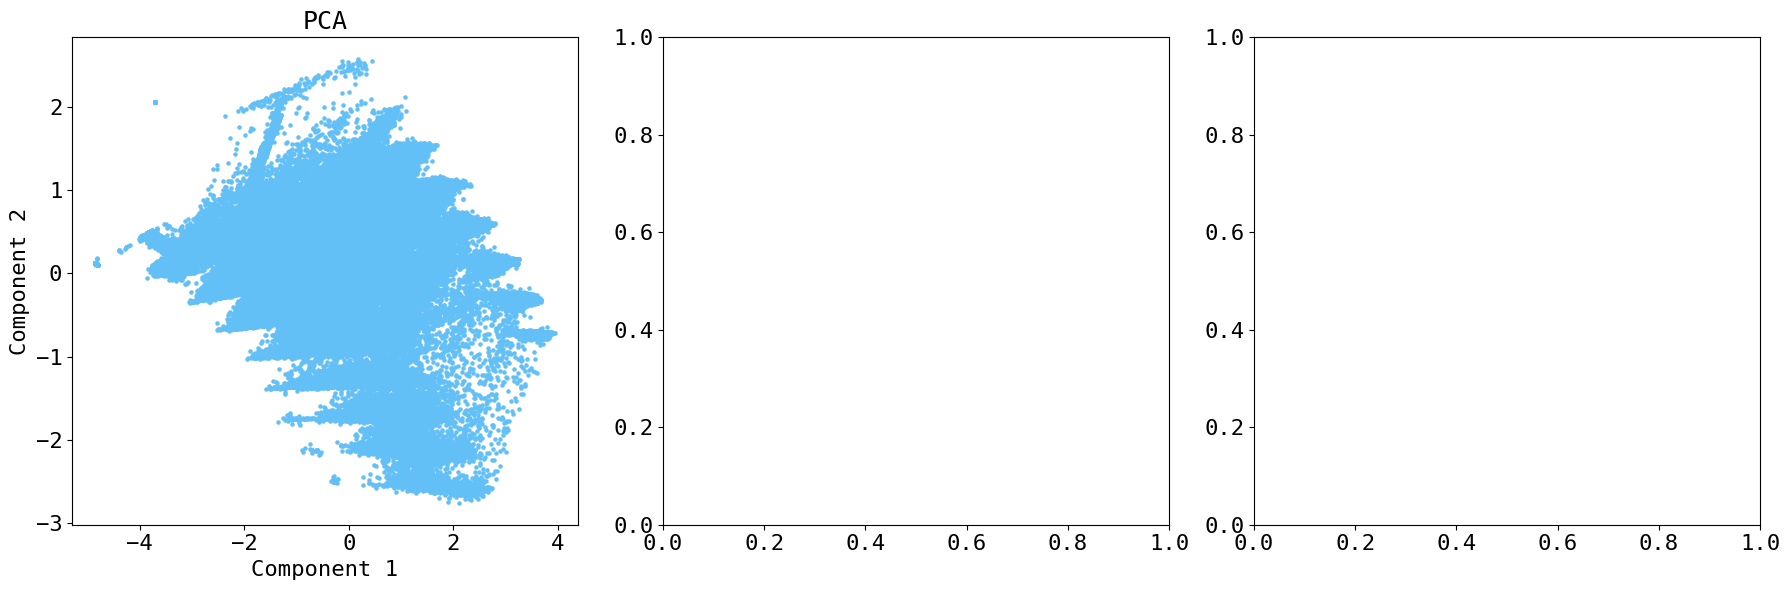

In [22]:
reducs = [y_pcs]#, y_tsne, y_umap]
labls = ['PCA']#, 't-SNE', 'UMAP']

fig, axes = plt.subplots(nrows = 1, ncols =3, figsize=(18, 6), dpi=100)
for i in range(1):
    # create a figure
    ax = axes[i]
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    # scatter plot using two principal components stored in y_pcs
    ax.scatter(reducs[i][:, 0], reducs[i][:, 1], s=5)
    ax.set_title(labls[i])
plt.tight_layout()
plt.show()